# ONNX & TensorRT & LibTorch 部署 Demo

本项目演示 PyTorch 模型的三种主流部署方式：
- **ONNX Runtime**：跨平台、跨框架的通用推理方案
- **TensorRT**：NVIDIA GPU 上的极致推理加速方案
- **LibTorch**：PyTorch 原生 C++ 推理方案

每种方式都包含 **Python 推理** 和 **C++ 推理** 的完整示例。

**模型规模**：SimpleMLP — **320 层** MLP，**33M 参数**（4 → 320×320 → 3），模型文件 ~126MB。

---
## 整体流程

```text
PyTorch 模型
    │
    ├─── torch.onnx.export() ──→ model.onnx ──┬──→ ONNX Runtime 推理（Python / C++）
    │                                          │
    │                                          └──→ trtexec ──→ model.engine ──→ TensorRT 推理（Python / C++）
    │
    ├─── torch.jit.trace() ──→ model.pt ──→ LibTorch C++ 推理（CPU / GPU）
    │
    └─── 共享同一个 SimpleMLP 模型（33M 参数）
```


---
## 项目结构

```text
ONNX_TensorRT_demo/
│
├── model/                          # ===== 模型定义 =====
│   ├── model.py                    # 共享模型定义（SimpleMLP, 33M 参数）
│   ├── weights.pth                 # 模型权重文件（运行后生成）
│   └── model.pt                    # TorchScript 模型（运行后生成）
│
├── onnx/                           # ===== ONNX 部署 =====
│   ├── export_onnx.py              # 导出 ONNX + 结构检查 + 数值精度对比
│   ├── infer_python.py             # ONNX Runtime Python 推理
│   ├── model.onnx                  # 导出的 ONNX 模型（运行后生成）
│   └── cpp/                        # C++ 推理与基准测试
│
├── tensorrt/                       # ===== TensorRT 部署 =====
│   ├── build_engine.py             # 构建 FP32/FP16 Engine
│   ├── infer_python.py             # TensorRT Python 推理
│   ├── model.engine                # FP32/FP16 Engine（运行后生成）
│   └── cpp/                        # C++ 推理与基准测试
│
├── libtorch/                       # ===== LibTorch 部署 =====
│   └── cpp/                        # C++ 基准测试（CPU + GPU）
│
├── third_party/                    # ===== C++ 第三方依赖 =====
│   ├── onnxruntime/                # ONNX Runtime C++ SDK
│   ├── TensorRT/                   # TensorRT C++ SDK（含 trtexec）
│   └── Libtorch/                   # LibTorch CPU SDK
│
├── benchmark.py                    # 推理速度对比基准测试
├── visualize.py                    # 可视化脚本
├── benchmark_results.json          # 测试结果（运行后生成）
├── benchmark_result.png            # 可视化图表（运行后生成）
│
└── demo介绍.ipynb                  # 本 notebook
```

## 各文件说明

| 文件 | 作用 |
|------|------|
| `model/model.py` | 定义 SimpleMLP（320层MLP：4→320×320→3，**33M 参数**） |
| `onnx/export_onnx.py` | 导出 ONNX + 结构检查 + 数值精度对比 |
| `onnx/infer_python.py` | ONNX Runtime Python 推理 |
| `onnx/cpp/main.cpp` | ONNX Runtime C++ 推理示例 |
| `onnx/cpp/benchmark.cpp` | ONNX Runtime C++ 基准测试（CPU/CUDA） |
| `tensorrt/build_engine.py` | 构建 FP32/FP16 Engine |
| `tensorrt/infer_python.py` | TensorRT Python 推理 |
| `tensorrt/cpp/main.cpp` | TensorRT C++ 推理示例 |
| `tensorrt/cpp/benchmark.cpp` | TensorRT C++ 基准测试 |
| `libtorch/cpp/main.cpp` | LibTorch C++ 推理示例（支持 CPU/GPU） |
| `libtorch/cpp/benchmark.cpp` | LibTorch C++ 基准测试（CPU/CUDA） |
| **`benchmark.py`** | **推理速度对比：分 CPU/GPU 两大类，对比 PyTorch/ONNX/TensorRT × Python/C++** |
| **`visualize.py`** | **可视化脚本：读取 benchmark_results.json，生成 2×2 对比图** |

---
## 环境配置

### 当前环境

| 组件 | 版本 |
|------|------|
| Python | 3.9 (conda env: `flow_planner`) |
| PyTorch | 2.0.1+cu118 |
| ONNX Runtime (Python) | 1.19.2 (GPU 版, Providers: CUDA + TensorRT + CPU) |
| TensorRT | 8.6.1 |
| CUDA | 12.1 |
| cuDNN | 8.9 (系统) / 9.x (NVIDIA pip 包, benchmark.py 自动加载) |
| GPU | NVIDIA GeForce GTX 1050 Ti |
| C++ 编译器 | GCC 11.4 |

### Python 依赖安装

```bash
pip install torch onnx onnxruntime-gpu tensorrt numpy matplotlib
```

> **注意**：`onnxruntime-gpu` 1.18+ 需要 cuDNN 9，`benchmark.py` 会自动从 conda 环境加载 cuDNN 9

### C++ 第三方依赖（已放置在 `third_party/` 下）

| 库 | 路径 | 说明 |
|----|------|------|
| ONNX Runtime | `third_party/onnxruntime/` | 1.26.0 GPU 版，含 CUDA + TensorRT provider |
| TensorRT | `third_party/TensorRT/` | 8.6.1，含 `libnvinfer.so`、`trtexec` |
| LibTorch | `third_party/Libtorch/` | CPU 版（备选）；GPU 版优先使用 conda 中的 torch |

---
# 第一部分：ONNX 部署

## Step 1：导出 ONNX 模型

导出 ONNX 并自动验证结构和数值精度：

In [14]:
# 运行导出
!python onnx/export_onnx.py

/home/zhangjinrui/anaconda3/envs/flow_planner/lib/python3.9/site-packages/torch/_utils.py:776: UserWarning: TypedStorage is deprecated. It will be removed in the future and UntypedStorage will be the only storage class. This should only matter to you if you are using storages directly.  To access UntypedStorage directly, use tensor.untyped_storage() instead of tensor.storage()
  return self.fget.__get__(instance, owner)()
已加载权重: /home/zhangjinrui/my_program_code/Data_Processing/python/torch/17_Model_Deployment/ONNX_TensorRT_demo/onnx/../model/weights.pth
============= Diagnostic Run torch.onnx.export version 2.0.1+cu118 =============
verbose: False, log level: Level.ERROR
======================= 0 NONE 0 NOTE 0 WARNING 0 ERROR ========================

ONNX 模型已导出到: /home/zhangjinrui/my_program_code/Data_Processing/python/torch/17_Model_Deployment/ONNX_TensorRT_demo/onnx/../onnx/model.onnx
✓ ONNX 结构检查通过

模型输入:
  input: ['batch_size', 4]
模型输出:
  output: ['batch_size', 3]
已加载权重: /home/zha

## Step 2：ONNX Runtime Python 推理

In [15]:
!python onnx/infer_python.py

输入名: input, shape: ['batch_size', 4], dtype: tensor(float)
输出名: output, shape: ['batch_size', 3], dtype: tensor(float)

输入数据:
[[1.  2.  3.  4. ]
 [0.5 1.5 2.5 3.5]]

输出结果:
[[-0.01563945  0.03882093 -0.00068012]
 [-0.01563945  0.03882093 -0.00068012]]
输出 shape: (2, 3)

--- 动态 batch 推理 ---
  batch_size=1: 输入 (1, 4) → 输出 (1, 3)
  batch_size=4: 输入 (4, 4) → 输出 (4, 3)
  batch_size=8: 输入 (8, 4) → 输出 (8, 3)

--- 连续 5 次推理 ---
  iter 0: 输出 [-0.01563945  0.03882093 -0.00068012]
  iter 1: 输出 [-0.01563945  0.03882093 -0.00068012]
  iter 2: 输出 [-0.01563945  0.03882094 -0.00068012]
  iter 3: 输出 [-0.01563945  0.03882093 -0.00068012]
  iter 4: 输出 [-0.01563945  0.03882094 -0.00068012]


## Step 3：ONNX Runtime C++ 推理

### 编译并运行

In [16]:
!mkdir -p onnx/cpp/build && cd onnx/cpp/build && cmake .. && make

-- ONNX Runtime CUDA provider found, building with GPU support
CMake Warning (dev) at CMakeLists.txt:23 (find_package):
  Policy CMP0146 is not set: The FindCUDA module is removed.  Run "cmake
  --help-policy CMP0146" for policy details.  Use the cmake_policy command to
  set the policy and suppress this warning.

This warning is for project developers.  Use -Wno-dev to suppress it.

-- Configuring done (0.0s)
-- Generating done (0.0s)
-- Build files have been written to: /home/zhangjinrui/my_program_code/Data_Processing/python/torch/17_Model_Deployment/ONNX_TensorRT_demo/onnx/cpp/build
[ 50%] Built target onnx_demo
[100%] Built target onnx_bench


In [17]:
!cd onnx/cpp/build && ./onnx_demo ../../model.onnx

模型加载成功: ../../model.onnx
输入: input
输出: output

输入数据:
1 2 3 4 
0.5 1.5 2.5 3.5 

输出 shape: [2, 3]
输出数据:
-0.0156395 0.0388209 -0.000680123 
-0.0156395 0.0388209 -0.00068012 

--- 连续 3 次推理 ---
  iter 0: -0.0156395 0.0388209 -0.000680124 
  iter 1: -0.0156395 0.0388209 -0.000680123 
  iter 2: -0.0156395 0.0388209 -0.000680122 


---
# 第二部分：TensorRT 部署

> **注意**：TensorRT 需要先安装。如未安装，请参考上方「环境配置」部分。

## Step 4：构建 TensorRT Engine

In [18]:
# 检查 trtexec 是否可用
import os, shutil
trtexec_paths = [
    shutil.which("trtexec"),
    os.path.join(os.getcwd(), "third_party", "TensorRT", "bin", "trtexec"),
]
found = [p for p in trtexec_paths if p and os.path.isfile(p)]
if found:
    print(f"✓ trtexec 已安装: {found[0]}")
else:
    print("✗ trtexec 未找到，请将其放到 third_party/TensorRT/bin/ 下")

✓ trtexec 已安装: /home/zhangjinrui/my_program_code/Data_Processing/python/torch/17_Model_Deployment/ONNX_TensorRT_demo/third_party/TensorRT/bin/trtexec


In [19]:
!python tensorrt/build_engine.py

使用 trtexec: /home/zhangjinrui/my_program_code/Data_Processing/python/torch/17_Model_Deployment/ONNX_TensorRT_demo/tensorrt/../third_party/TensorRT/bin/trtexec
构建命令: /home/zhangjinrui/my_program_code/Data_Processing/python/torch/17_Model_Deployment/ONNX_TensorRT_demo/tensorrt/../third_party/TensorRT/bin/trtexec --onnx=/home/zhangjinrui/my_program_code/Data_Processing/python/torch/17_Model_Deployment/ONNX_TensorRT_demo/tensorrt/../onnx/model.onnx --saveEngine=/home/zhangjinrui/my_program_code/Data_Processing/python/torch/17_Model_Deployment/ONNX_TensorRT_demo/tensorrt/../tensorrt/model.engine --minShapes=input:1x4 --optShapes=input:8x4 --maxShapes=input:64x4
构建中（可能需要几十秒）...
✓ Engine 已保存到: /home/zhangjinrui/my_program_code/Data_Processing/python/torch/17_Model_Deployment/ONNX_TensorRT_demo/tensorrt/../tensorrt/model.engine
  [06/09/2026-01:32:57] [I] Average on 10 runs - GPU latency: 6.85926 ms - Host latency: 6.87789 ms (enqueue 1.36696 ms)
  [06/09/2026-01:32:57] [I] Average on 10 runs 

## Step 5：TensorRT Python 推理

In [20]:
!python tensorrt/infer_python.py

Engine 加载成功: /home/zhangjinrui/my_program_code/Data_Processing/python/torch/17_Model_Deployment/ONNX_TensorRT_demo/tensorrt/../tensorrt/model.engine
  输入输出数量: 2

--- 基本推理 ---
输入:
[[1.  2.  3.  4. ]
 [0.5 1.5 2.5 3.5]]
输出:
[[-0.01563945  0.03882094 -0.00068012]
 [-0.01563945  0.03882094 -0.00068012]]
输出 shape: (2, 3)

--- 动态 batch 推理 ---
  batch=1: 输入 (1, 4) → 输出 (1, 3)
  batch=4: 输入 (4, 4) → 输出 (4, 3)
  batch=8: 输入 (8, 4) → 输出 (8, 3)

--- 连续 5 次推理 ---
  iter 0: 输出 [-0.01563945  0.03882094 -0.00068012]
  iter 1: 输出 [-0.01563945  0.03882094 -0.00068013]
  iter 2: 输出 [-0.01563945  0.03882094 -0.00068012]
  iter 3: 输出 [-0.01563945  0.03882094 -0.00068012]
  iter 4: 输出 [-0.01563945  0.03882093 -0.00068012]


## Step 6：TensorRT C++ 推理

### 编译并运行

In [21]:
!mkdir -p tensorrt/cpp/build && cd tensorrt/cpp/build && cmake .. && make

CMake Warning (dev) at CMakeLists.txt:11 (find_package):
  Policy CMP0146 is not set: The FindCUDA module is removed.  Run "cmake
  --help-policy CMP0146" for policy details.  Use the cmake_policy command to
  set the policy and suppress this warning.

This warning is for project developers.  Use -Wno-dev to suppress it.

-- Configuring done (0.0s)
-- Generating done (0.0s)
-- Build files have been written to: /home/zhangjinrui/my_program_code/Data_Processing/python/torch/17_Model_Deployment/ONNX_TensorRT_demo/tensorrt/cpp/build
[ 50%] Built target trt_demo
[100%] Built target trt_bench


In [22]:
# 设置 LD_LIBRARY_PATH 以找到 TensorRT 动态库
import os
os.environ["LD_LIBRARY_PATH"] = os.path.join(os.getcwd(), "third_party", "TensorRT", "lib") + ":" + os.environ.get("LD_LIBRARY_PATH", "")
!cd tensorrt/cpp/build && ./trt_demo ../../model.engine

Engine 加载成功: ../../model.engine
输入名: input
输出名: output
输出 shape: [2, 3]

输入数据:
1 2 3 4 
0.5 1.5 2.5 3.5 

输出数据:
-0.0156395 0.0388209 -0.000680122 
-0.0156395 0.0388209 -0.000680123 

--- 连续 3 次推理 ---
  iter 0: -0.0156395 0.0388209 -0.000680123 
  iter 1: -0.0156395 0.0388209 -0.000680124 
  iter 2: -0.0156395 0.0388209 -0.000680123 

资源已释放，完成。


---
# 第三部分：LibTorch 部署

> LibTorch 是 PyTorch 官方的 C++ 推理方案，直接加载 TorchScript 模型（`.pt`），无需转换格式。
> 适合不想引入 ONNX/TensorRT 额外依赖、但仍需要 C++ 部署的场景。

## Step 7：导出 TorchScript 模型

使用 `torch.jit.trace` 将当前模型导出为 TorchScript 格式：

In [23]:
# 导出 TorchScript 模型
import torch
import sys
sys.path.insert(0, ".")
from model.model import SimpleMLP

model = SimpleMLP()
model.load_state_dict(torch.load("model/weights.pth", map_location="cpu"))
model.eval()

dummy = torch.randn(1, 4)
traced = torch.jit.trace(model, dummy)
traced.save("model/model.pt")
print(f"TorchScript 模型已导出: model/model.pt")
print(f"验证输出: {traced(dummy)}")

TorchScript 模型已导出: model/model.pt
验证输出: tensor([[-0.0156,  0.0388, -0.0007]], grad_fn=<AddmmBackward0>)


## Step 8：LibTorch C++ 推理

### 编译

In [24]:
!mkdir -p libtorch/cpp/build && cd libtorch/cpp/build && CONDA_PREFIX=$HOME/anaconda3/envs/flow_planner cmake .. && make -j4

-- Using GPU libtorch from: /home/zhangjinrui/anaconda3/envs/flow_planner/lib/python3.9/site-packages/torch
-- Caffe2: CUDA detected: 12.1
-- Caffe2: CUDA nvcc is: /usr/local/cuda-12.1/bin/nvcc
-- Caffe2: CUDA toolkit directory: /usr/local/cuda-12.1
-- Caffe2: Header version is: 12.1
-- /usr/local/cuda-12.1/lib64/libnvrtc.so shorthash is b51b459d
-- USE_CUDNN is set to 0. Compiling without cuDNN support
-- Autodetected CUDA architecture(s):  6.1
-- Added CUDA NVCC flags for: -gencode;arch=compute_61,code=sm_61
CMake Warning at /home/zhangjinrui/anaconda3/envs/flow_planner/lib/python3.9/site-packages/torch/share/cmake/Torch/TorchConfig.cmake:22 (message):
  static library kineto_LIBRARY-NOTFOUND not found.
Call Stack (most recent call first):
  /home/zhangjinrui/anaconda3/envs/flow_planner/lib/python3.9/site-packages/torch/share/cmake/Torch/TorchConfig.cmake:127 (append_torchlib_if_found)
  CMakeLists.txt:25 (find_package)


-- CUDA support enabled
-- Configuring done (2.3s)
-- Generati

### 运行（CPU）

In [25]:
!cd libtorch/cpp/build && ./libtorch_demo ../../model/model.pt cpu

使用设备: CPU
模型加载失败: open file failed because of errno 2 on fopen: , file path: ../../model/model.pt
Exception raised from RAIIFile at ../caffe2/serialize/file_adapter.cc:21 (most recent call first):
frame #0: c10::Error::Error(c10::SourceLocation, std::string) + 0x57 (0x7259e32b84d7 in /home/zhangjinrui/anaconda3/envs/flow_planner/lib/python3.9/site-packages/torch/lib/libc10.so)
frame #1: c10::detail::torchCheckFail(char const*, char const*, unsigned int, std::string const&) + 0x64 (0x7259e328236b in /home/zhangjinrui/anaconda3/envs/flow_planner/lib/python3.9/site-packages/torch/lib/libc10.so)
frame #2: caffe2::serialize::FileAdapter::RAIIFile::RAIIFile(std::string const&) + 0x124 (0x7259cd6f9bf4 in /home/zhangjinrui/anaconda3/envs/flow_planner/lib/python3.9/site-packages/torch/lib/libtorch_cpu.so)
frame #3: caffe2::serialize::FileAdapter::FileAdapter(std::string const&) + 0x2e (0x7259cd6f9c4e in /home/zhangjinrui/anaconda3/envs/flow_planner/lib/python3.9/site-packages/torch/lib/libtorch

### 运行（GPU）

In [26]:
!cd libtorch/cpp/build && ./libtorch_demo ../../model/model.pt cuda

使用设备: CUDA (GPU 0)
模型加载失败: open file failed because of errno 2 on fopen: , file path: ../../model/model.pt
Exception raised from RAIIFile at ../caffe2/serialize/file_adapter.cc:21 (most recent call first):
frame #0: c10::Error::Error(c10::SourceLocation, std::string) + 0x57 (0x754645c4e4d7 in /home/zhangjinrui/anaconda3/envs/flow_planner/lib/python3.9/site-packages/torch/lib/libc10.so)
frame #1: c10::detail::torchCheckFail(char const*, char const*, unsigned int, std::string const&) + 0x64 (0x754645c1836b in /home/zhangjinrui/anaconda3/envs/flow_planner/lib/python3.9/site-packages/torch/lib/libc10.so)
frame #2: caffe2::serialize::FileAdapter::RAIIFile::RAIIFile(std::string const&) + 0x124 (0x7546300f9bf4 in /home/zhangjinrui/anaconda3/envs/flow_planner/lib/python3.9/site-packages/torch/lib/libtorch_cpu.so)
frame #3: caffe2::serialize::FileAdapter::FileAdapter(std::string const&) + 0x2e (0x7546300f9c4e in /home/zhangjinrui/anaconda3/envs/flow_planner/lib/python3.9/site-packages/torch/lib

---
## 关键 API 对照表

| 操作 | ONNX Runtime (Python) | ONNX Runtime (C++) | TensorRT (Python) | TensorRT (C++) | LibTorch (C++) |
|------|----------------------|-------------------|-------------------|----------------|----------------|
| 加载模型 | `ort.InferenceSession(path)` | `Ort::Session(env, path, opts)` | `runtime.deserialize_cuda_engine(bytes)` | `runtime->deserializeCudaEngine(data, size)` | `torch::jit::load(path)` |
| 构造输入 | numpy array | `Ort::Value::CreateTensor()` | numpy + `cuda.memcpy_htod()` | `cudaMemcpy()` | `torch::tensor({})` / `.to(device)` |
| 推理 | `session.run(None, {name: data})` | `session.Run(...)` | `context.execute_async_v3(stream)` | `context->enqueueV3(stream)` | `module.forward(inputs).toTensor()` |
| 取输出 | `outputs[0]` (numpy) | `GetTensorMutableData<float>()` | `cuda.memcpy_dtoh()` | `cudaMemcpy()` | `output.cpu()` / `.item<float>()` |
| GPU 支持 | provider 参数 | `AppendExecutionProvider_CUDA` | 仅 GPU | 仅 GPU | `module.to(kCUDA)` |

## 三种方案选型

| 维度 | ONNX Runtime | TensorRT | LibTorch |
|------|-------------|----------|----------|
| 硬件支持 | CPU + GPU + 多平台 | 仅 NVIDIA GPU | CPU + GPU |
| 部署难度 | 低（pip install 即可） | 中（需安装 TensorRT SDK） | 低（conda torch 自带） |
| GPU 推理速度 | 良好（图优化） | 极致（算子融合 + 低精度） | 一般（无图优化） |
| 精度模式 | FP32 / FP16 | FP32 / FP16 / INT8 | FP32 / FP16 |
| 动态 Shape | 原生支持 | 需指定 min/opt/max 范围 | 原生支持 |
| 模型格式 | .onnx | .engine | .pt (TorchScript) |
| 适用场景 | 通用部署、CPU 推理 | GPU 极致性能 | 不想转换格式、快速原型 |

## 常见问题

**Q: ONNX 导出时报 Unsupported operator？**  
A: 提高 `opset_version`（如 17），或先用 `torch.jit.script` 转 TorchScript 再导出。

**Q: ONNX Runtime C++ 编译找不到头文件？**  
A: 确认已下载 ONNX Runtime 预编译包并放到 `third_party/onnxruntime/` 下，检查 `CMakeLists.txt` 中的 `ORT_ROOT` 路径。

**Q: TensorRT build_engine.py 报 trtexec 找不到？**  
A: 脚本会自动检测 `trtexec`（系统 PATH 或 `third_party/TensorRT/bin/`），如都不可用会自动回退到 Python API 构建。

**Q: LibTorch 编译报 "Cannot find libtorch"？**  
A: 确保设置 `CONDA_PREFIX` 环境变量指向你的 conda 环境，或将 LibTorch SDK 放到 `third_party/Libtorch/` 下。

**Q: LibTorch GPU 模式报 "CUDA 不可用"？**  
A: 需要使用 GPU 版本的 libtorch。CMakeLists.txt 优先使用 conda 环境中的 GPU torch（自动检测），如只有 `third_party/Libtorch/` 下的 CPU 版本则不支持 GPU。

**Q: ONNX 和 TensorRT 输出数值有差异？**  
A: 正常现象。TensorRT 的算子融合和低精度优化会引入微小误差，一般在 1e-3 量级内可接受。

---
# 第四部分：推理速度对比基准测试

> 分 **CPU** 和 **GPU** 两大类，全面对比：
> - PyTorch (Python + C++/LibTorch)
> - ONNX Runtime (Python + C++)
> - TensorRT FP32/FP16 (Python + C++)
>
> **测试方法**：每种方式先做 20 次预热，再做 200 次正式计时，统计平均/中位数/P95/P99 等指标。
>
> **前置条件**：需要先编译 C++ benchmark 程序（如果还没编译，取消下面的注释）：

In [27]:
# 编译所有 C++ 基准测试程序
!mkdir -p onnx/cpp/build && cd onnx/cpp/build && cmake .. && make -j4
!mkdir -p tensorrt/cpp/build && cd tensorrt/cpp/build && cmake .. && make -j4
!mkdir -p libtorch/cpp/build && cd libtorch/cpp/build && CONDA_PREFIX=$HOME/anaconda3/envs/flow_planner cmake .. && make -j4

-- ONNX Runtime CUDA provider found, building with GPU support
CMake Warning (dev) at CMakeLists.txt:23 (find_package):
  Policy CMP0146 is not set: The FindCUDA module is removed.  Run "cmake
  --help-policy CMP0146" for policy details.  Use the cmake_policy command to
  set the policy and suppress this warning.

This warning is for project developers.  Use -Wno-dev to suppress it.

-- Configuring done (0.0s)
-- Generating done (0.0s)
-- Build files have been written to: /home/zhangjinrui/my_program_code/Data_Processing/python/torch/17_Model_Deployment/ONNX_TensorRT_demo/onnx/cpp/build
[ 50%] Built target onnx_bench
[100%] Built target onnx_demo
CMake Warning (dev) at CMakeLists.txt:11 (find_package):
  Policy CMP0146 is not set: The FindCUDA module is removed.  Run "cmake
  --help-policy CMP0146" for policy details.  Use the cmake_policy command to
  set the policy and suppress this warning.

This warning is for project developers.  Use -Wno-dev to suppress it.

-- Configuring done (

In [28]:
# 运行推理速度对比基准测试（自动调用 C++ 程序）
!python benchmark.py

                                           推理速度对比基准测试                                          
预热: 20 次    测试: 200 次
PyTorch: 2.0.1+cu118    CUDA: True  (NVIDIA GeForce GTX 1050 Ti)
ONNX Runtime: 1.19.2    Providers: ['TensorrtExecutionProvider', 'CUDAExecutionProvider', 'CPUExecutionProvider']
TensorRT: 8.6.1
C++ ONNX Bench: ✓
C++ TRT  Bench: ✓
C++ LibTorch:   ✓
trtexec: ✗ (未找到，Engine 构建将使用 Python API)
/home/zhangjinrui/anaconda3/envs/flow_planner/lib/python3.9/site-packages/torch/_utils.py:776: UserWarning: TypedStorage is deprecated. It will be removed in the future and UntypedStorage will be the only storage class. This should only matter to you if you are using storages directly.  To access UntypedStorage directly, use tensor.untyped_storage() instead of tensor.storage()
  return self.fget.__get__(instance, owner)()
已加载权重: /home/zhangjinrui/my_program_code/Data_Processing/python/torch/17_Model_Deployment/ONNX_TensorRT_demo/model/weights.pth

──────────────────────────────────────

## 结果分析（33M 参数 / 320 层深度窄层模型）

> **计时标准**：所有方法统一为 warmup(20次) → [sync → inference → sync → 记录耗时] × 200 次。

### CPU 推理对比

| 推理方式 | Batch=1 | Batch=8 | Batch=32 | 平均加速比 |
|---------|:-------:|:-------:|:--------:|:---------:|
| PyTorch CPU (Python) | 13.0ms | 13.9ms | 20.6ms | 1.0x 基准 |
| **ONNX Runtime CPU (C++)** | **5.5ms** | **6.8ms** | **11.6ms** | **~2.0x** |
| PyTorch CPU (C++ / LibTorch) | 8.0ms | 11.1ms | 16.4ms | ~1.4x |
| ONNX Runtime CPU (Python) | 6.0ms | 6.6ms | 12.7ms | ~1.8x |

### GPU 推理对比

| 推理方式 | Batch=1 | Batch=8 | Batch=32 | 加速比 |
|---------|:-------:|:-------:|:--------:|:------:|
| PyTorch GPU (Python) | 13.2ms | 11.9ms | 14.7ms | 1.0x |
| PyTorch GPU (C++ / LibTorch) | 7.9ms | 7.0ms | 10.2ms | ~1.6x |
| TensorRT FP32 (C++) | 6.4ms | 6.5ms | 6.6ms | ~2.1x |
| TensorRT FP16 (C++) | 6.4ms | 6.5ms | 6.6ms | ~2.1x |
| ONNX Runtime GPU (Python) | 3.9ms | 4.1ms | 4.2ms | ~3.2x |
| **ONNX Runtime GPU (C++)** | **3.5ms** | **4.1ms** | **4.1ms** | **~3.4x** |

### 核心发现

1. **ONNX Runtime GPU (C++) 最快** — 比 TensorRT C++ 快 **~1.7x**，比 LibTorch GPU 快 **~2.2x**，比 PyTorch GPU Python 快 **~3.4x**。

2. **C++ 比 Python 快 1.5–2x** — LibTorch GPU C++ (7.9ms) vs PyTorch GPU Python (13.2ms)；LibTorch CPU C++ (8.0ms) vs PyTorch CPU Python (13.0ms)。

3. **LibTorch 处于中间位置** — 比 PyTorch Python 快（消除了 Python 开销），但比 ONNX Runtime 慢（缺少图级优化如 Layer Fusion）。

4. **TensorRT 在深度窄层模型上不如 ORT** — 320 层连续小算子，ORT 的图融合效率更高。

5. **FP32 ≈ FP16** — GTX 1050 Ti (Pascal) 没有 Tensor Core，FP16 不加速。

> 💡 **实践建议**：
> - **深度窄层模型**：优先 **ONNX Runtime GPU (C++)**
> - **宽层大模型**：优先 **TensorRT FP16 (C++)**
> - **不想转换格式**：**LibTorch C++** 是最简单的原生方案

In [29]:
# 生成可视化对比图表
!python visualize.py

图表已保存: /home/zhangjinrui/my_program_code/Data_Processing/python/torch/17_Model_Deployment/ONNX_TensorRT_demo/benchmark_result.png


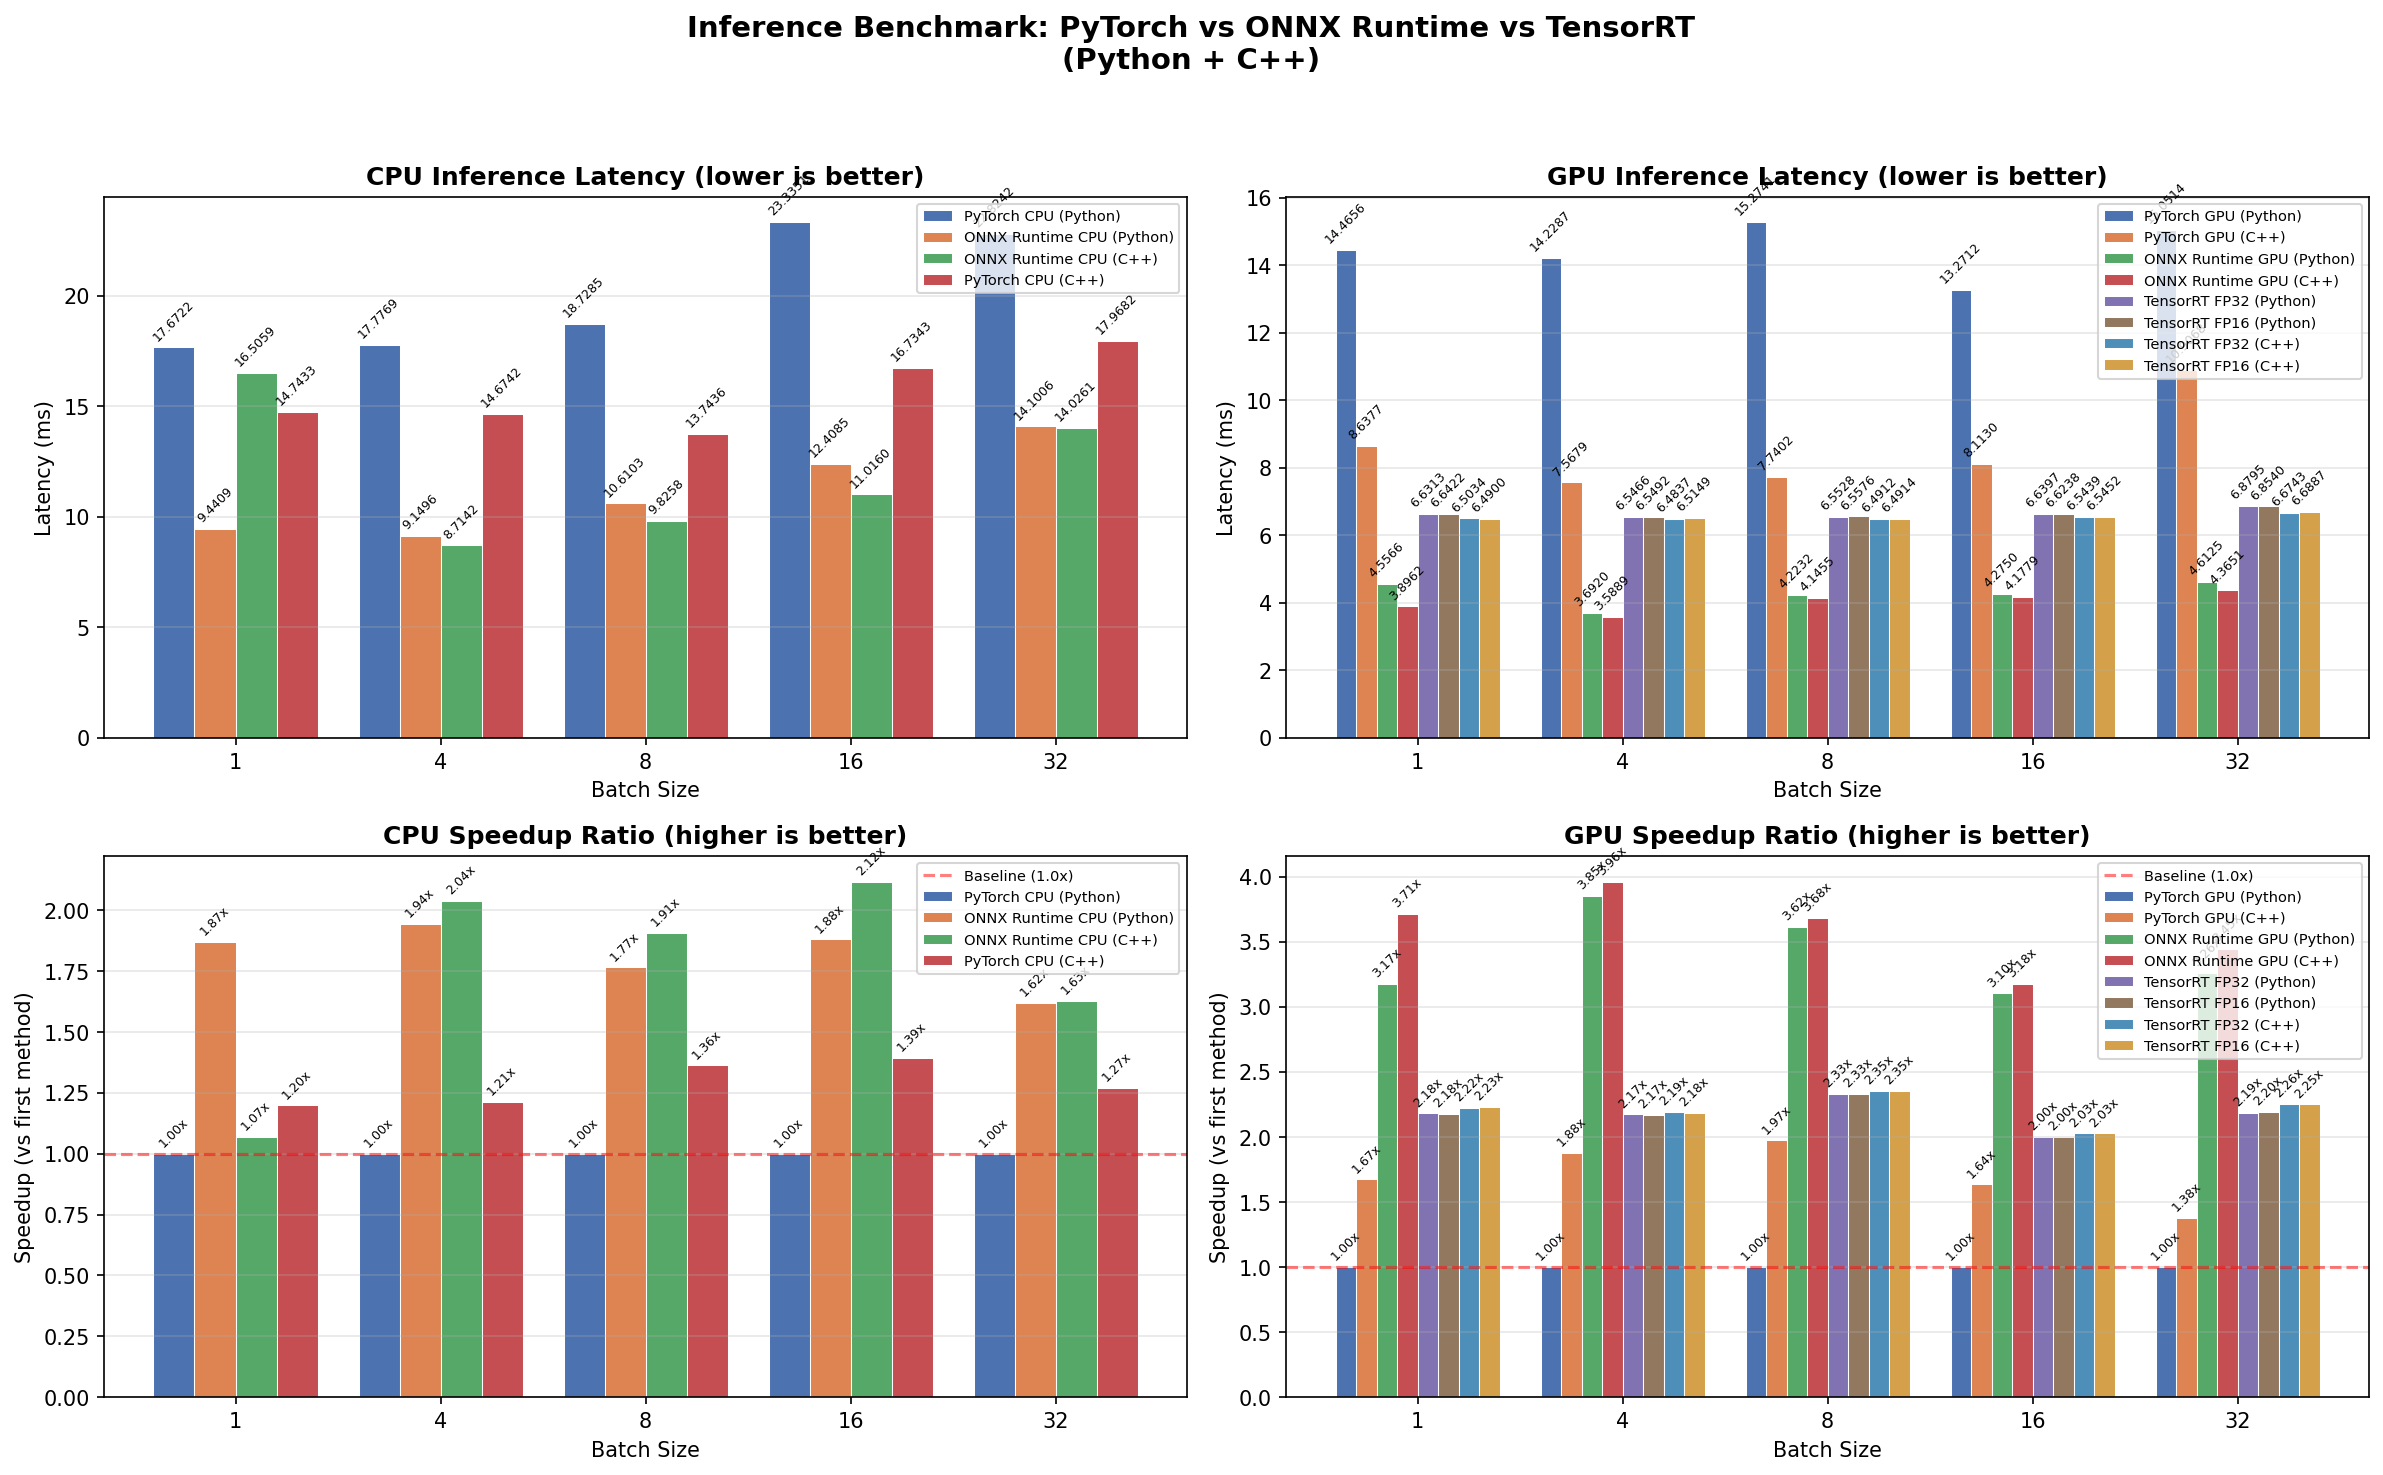

In [30]:
# 显示生成的图表
from IPython.display import Image
Image(filename="benchmark_result.png")